#### Credit Card Fraud Detection — EDA

This notebook explores the Kaggle **Credit Card Fraud Detection** dataset.

**Expected path:** `data/raw/creditcard.csv`

Key goals:
- Understand class imbalance (fraud is rare)
- Check missing values and basic stats
- Explore distributions (`Time`, `Amount`, PCA components)
- Quick correlation signals
- Baseline model evaluation (ROC-AUC + PR-AUC)
- **Extras for recruiters:** feature importance + threshold optimization

> Note: For highly imbalanced problems, **PR-AUC / Average Precision** is often more informative than ROC-AUC.


In [3]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

DATA_PATH = os.path.join("..", "data", "raw", "creditcard.csv")
#print("DATA_PATH:", os.path.abspath(DATA_PATH))


In [4]:
# Load dataset
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find dataset at: {os.path.abspath(DATA_PATH)}\n"
        "Place creditcard.csv into data/raw/creditcard.csv"
    )

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1) Schema and missing values

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]


Series([], dtype: int64)

## 2) Class imbalance (count + ratio)

,count,ratio
Class,,
0,284315,0.998273
1,492,0.001727


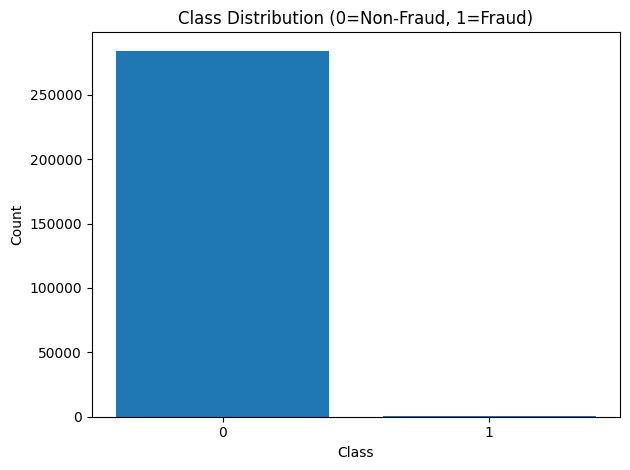

In [7]:
class_counts = df["Class"].value_counts().sort_index()
class_ratio = class_counts / len(df)

display(pd.DataFrame({"count": class_counts, "ratio": class_ratio}))

plt.figure()
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution (0=Non-Fraud, 1=Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 3) Summary statistics

In [8]:
df.describe().T.head(12)

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 4) Amount and Time distributions

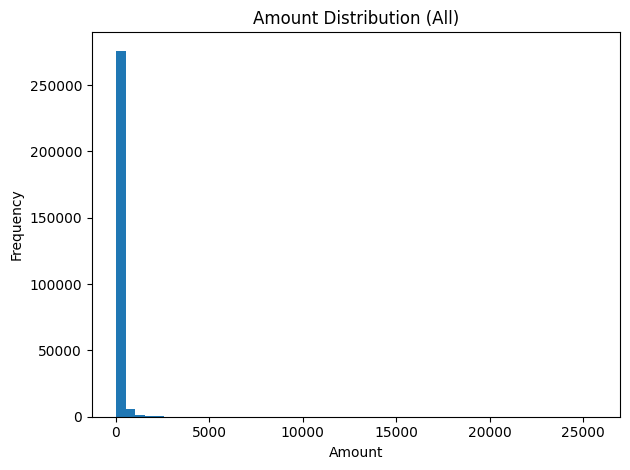

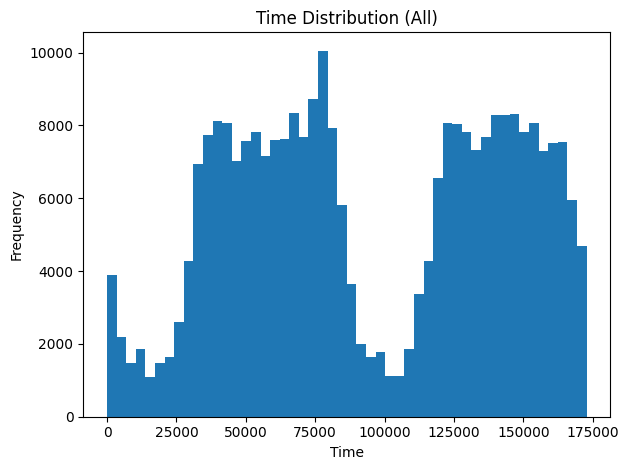

In [9]:
# Histograms (all)
plt.figure()
plt.hist(df["Amount"], bins=50)
plt.title("Amount Distribution (All)")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(df["Time"], bins=50)
plt.title("Time Distribution (All)")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


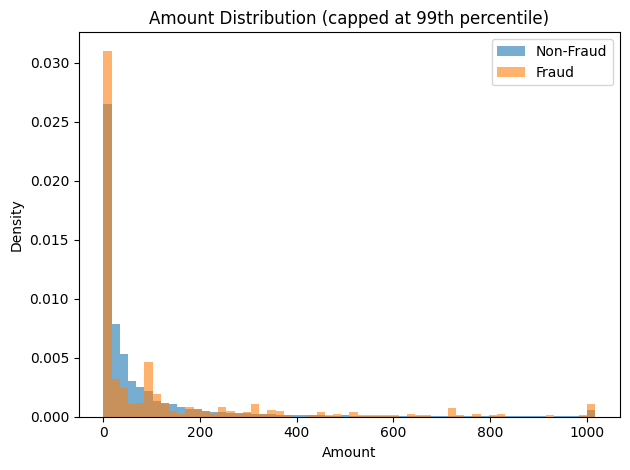

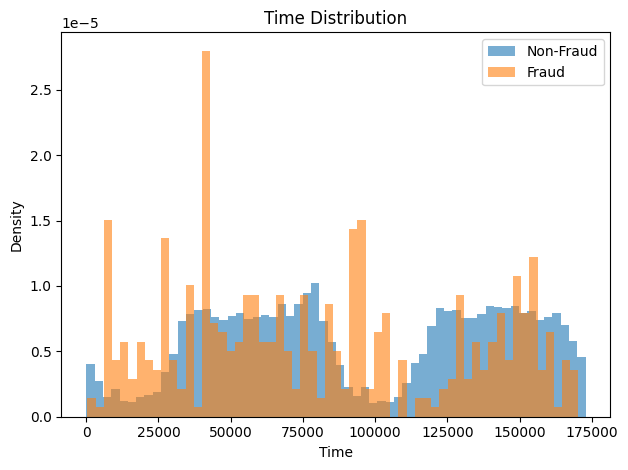

In [10]:
# Compare fraud vs non-fraud for Amount and Time
fraud = df[df["Class"] == 1]
nonfraud = df[df["Class"] == 0]

# Use percentile cap for Amount to keep plot readable
cap = np.percentile(df["Amount"], 99)

plt.figure()
plt.hist(nonfraud["Amount"].clip(upper=cap), bins=60, alpha=0.6, label="Non-Fraud", density=True)
plt.hist(fraud["Amount"].clip(upper=cap), bins=60, alpha=0.6, label="Fraud", density=True)
plt.title("Amount Distribution (capped at 99th percentile)")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(nonfraud["Time"], bins=60, alpha=0.6, label="Non-Fraud", density=True)
plt.hist(fraud["Time"], bins=60, alpha=0.6, label="Fraud", density=True)
plt.title("Time Distribution")
plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


## 5) PCA component distributions (sample V1–V6)

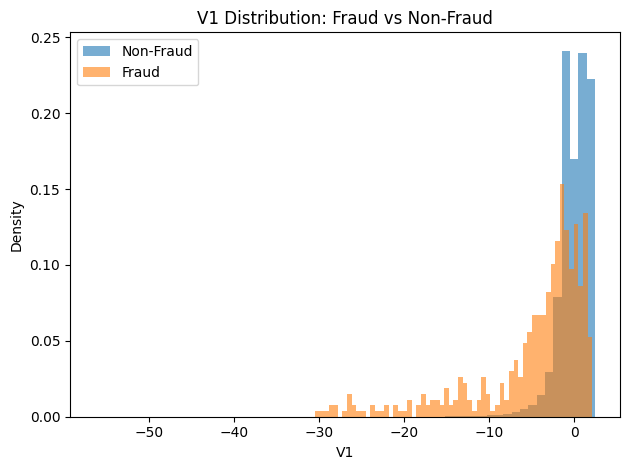

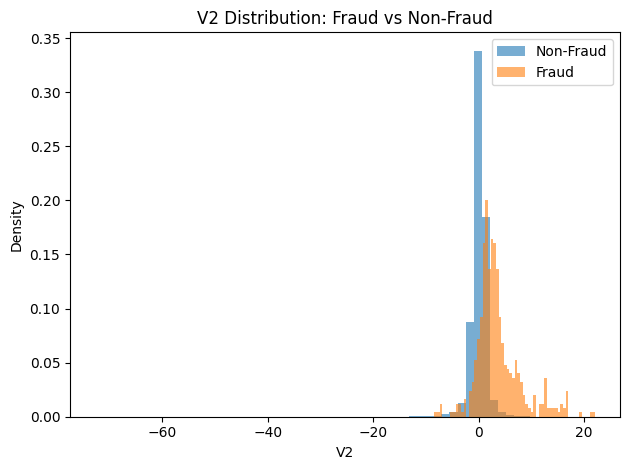

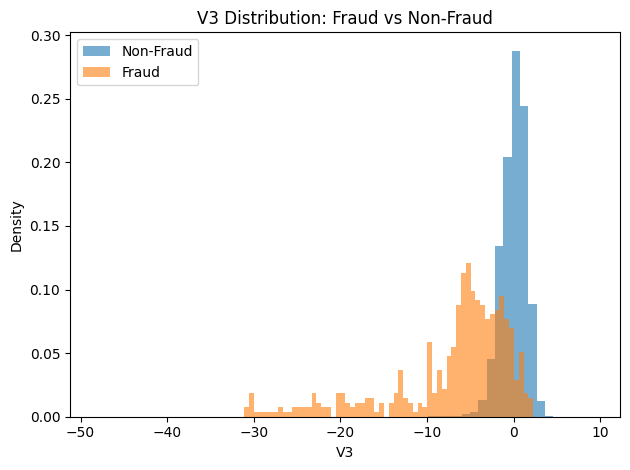

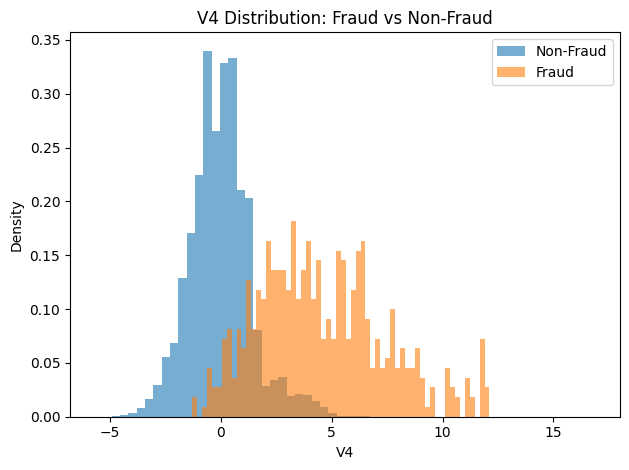

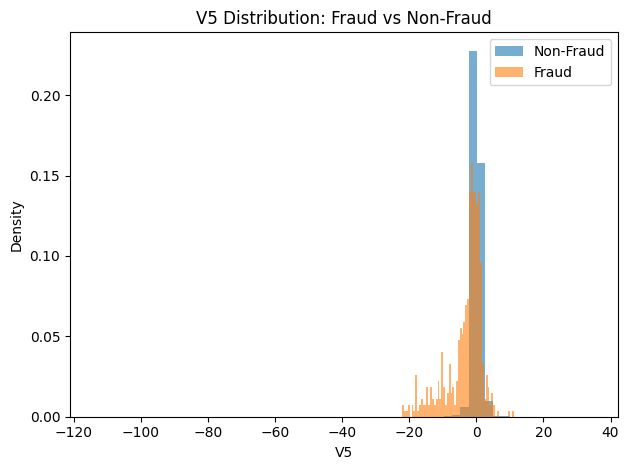

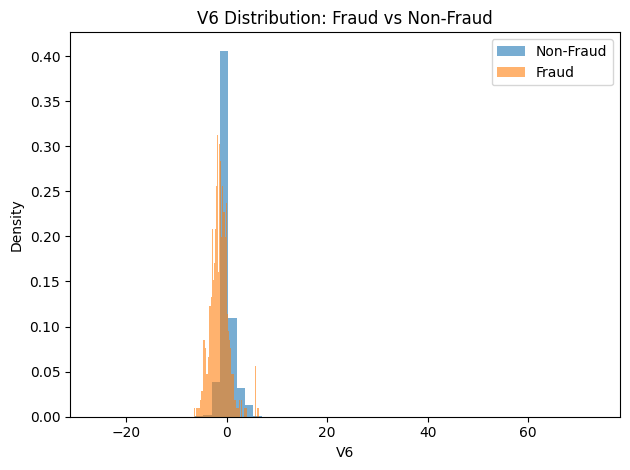

In [11]:
pca_cols = [c for c in df.columns if c.startswith("V")]
sample_cols = pca_cols[:6]

for col in sample_cols:
    plt.figure()
    plt.hist(nonfraud[col], bins=60, alpha=0.6, label="Non-Fraud", density=True)
    plt.hist(fraud[col], bins=60, alpha=0.6, label="Fraud", density=True)
    plt.title(f"{col} Distribution: Fraud vs Non-Fraud")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 6) Correlation with Class (quick signal)

,corr_with_class
Class,1.000000
V11,0.154876
V4,0.133447
V2,0.091289
V21,0.040413
V19,0.034783
V20,0.020090
V8,0.019875
V27,0.017580
V28,0.009536


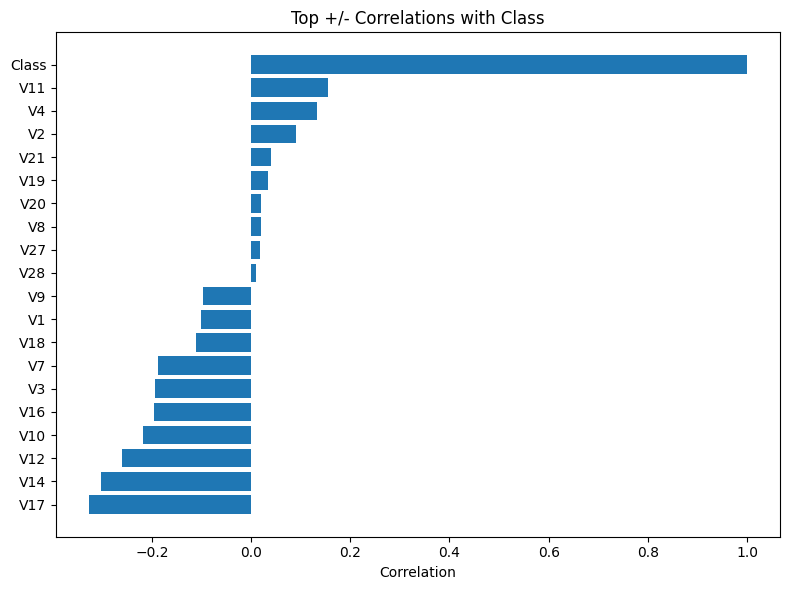

In [14]:
corr = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
display(pd.DataFrame({"corr_with_class": corr}))

top = pd.concat([corr.head(10), corr.tail(10)]).drop_duplicates()
plt.figure(figsize=(8, 6))
plt.barh(top.index[::-1], top.values[::-1])
plt.title("Top +/- Correlations with Class")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()


## 7) Baseline model (Logistic Regression)
We’ll build a simple baseline:
- Drop `Time`
- Scale `Amount`
- Train/test split (stratified)
- Fit Logistic Regression with `class_weight='balanced'`
- Evaluate ROC-AUC + PR-AUC


In [15]:
# Prepare features
X = df.drop(["Class", "Time"], axis=1).copy()
y = df["Class"].copy()

# Scale Amount into Amount_scaled
scaler = StandardScaler()
X["Amount_scaled"] = scaler.fit_transform(X["Amount"].values.reshape(-1, 1))
X.drop(columns=["Amount"], inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline = LogisticRegression(max_iter=3000, class_weight="balanced", n_jobs=None)
baseline.fit(X_train, y_train)

proba = baseline.predict_proba(X_test)[:, 1]
pred = baseline.predict(X_test)

roc = roc_auc_score(y_test, proba)
ap = average_precision_score(y_test, proba)  # PR-AUC summary

print("ROC-AUC:", roc)
print("Average Precision (PR-AUC):", ap)
print("\nClassification report:\n", classification_report(y_test, pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))


ROC-AUC: 0.9714465520310545
Average Precision (PR-AUC): 0.7155864892965794

Classification report:
               precision    recall  f1-score   support

           0     0.9999    0.9747    0.9871     56864
           1     0.0588    0.9184    0.1105        98

    accuracy                         0.9746     56962
   macro avg     0.5293    0.9465    0.5488     56962
weighted avg     0.9982    0.9746    0.9856     56962

Confusion matrix:
 [[55423  1441]
 [    8    90]]


## 8) Precision–Recall Curve (baseline)

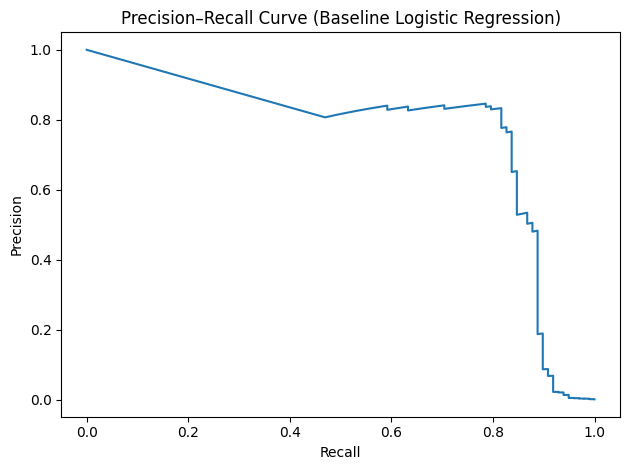

In [16]:
precision, recall, thresholds = precision_recall_curve(y_test, proba)

plt.figure()
plt.plot(recall, precision)
plt.title("Precision–Recall Curve (Baseline Logistic Regression)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()


## 9) EXTRA: Threshold optimization
Because fraud detection is imbalanced, the default threshold (0.5) is rarely optimal.

We will compute:
- Threshold that maximizes **F1**
- Threshold that achieves **>= 90% recall** (catch most fraud) with the best precision


In [17]:
def f1_from_pr(precision, recall):
    # Avoid divide-by-zero
    denom = (precision + recall)
    return np.where(denom == 0, 0, 2 * precision * recall / denom)

# precision_recall_curve returns thresholds with length = len(precision)-1
# We'll compute F1 for the points aligned with thresholds.
f1_scores = f1_from_pr(precision[:-1], recall[:-1])

best_f1_idx = int(np.argmax(f1_scores))
best_f1_threshold = float(thresholds[best_f1_idx])
best_f1_value = float(f1_scores[best_f1_idx])

print("Best-F1 threshold:", best_f1_threshold)
print("Best F1:", best_f1_value)

# Recall constraint threshold (>= 0.90): among those points, maximize precision
target_recall = 0.90
eligible = np.where(recall[:-1] >= target_recall)[0]
if len(eligible) == 0:
    print("No threshold achieves recall >=", target_recall)
    best_recall_threshold = None
else:
    best_prec_idx = eligible[np.argmax(precision[:-1][eligible])]
    best_recall_threshold = float(thresholds[best_prec_idx])
    print("Threshold for recall >=", target_recall, ":", best_recall_threshold)
    print("Precision at that threshold:", float(precision[:-1][best_prec_idx]))
    print("Recall at that threshold:", float(recall[:-1][best_prec_idx]))

def evaluate_at_threshold(y_true, y_prob, threshold):
    y_hat = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    report = classification_report(y_true, y_hat, digits=4)
    return cm, report

# Evaluate both thresholds
cm_f1, rep_f1 = evaluate_at_threshold(y_test, proba, best_f1_threshold)
print("\n=== Evaluation at Best-F1 Threshold ===")
print("Confusion matrix:\n", cm_f1)
print(rep_f1)

if best_recall_threshold is not None:
    cm_r, rep_r = evaluate_at_threshold(y_test, proba, best_recall_threshold)
    print("\n=== Evaluation at Recall>=90% Threshold ===")
    print("Confusion matrix:\n", cm_r)
    print(rep_r)


Best-F1 threshold: 0.9999999335081486
Best F1: 0.8247422680412372
Threshold for recall >= 0.9 : 0.6172956528757291
Precision at that threshold: 0.08811881188118811
Recall at that threshold: 0.9081632653061225

=== Evaluation at Best-F1 Threshold ===
Confusion matrix:
 [[56848    16]
 [   18    80]]
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8333    0.8163    0.8247        98

    accuracy                         0.9994     56962
   macro avg     0.9165    0.9080    0.9122     56962
weighted avg     0.9994    0.9994    0.9994     56962


=== Evaluation at Recall>=90% Threshold ===
Confusion matrix:
 [[55943   921]
 [    9    89]]
              precision    recall  f1-score   support

           0     0.9998    0.9838    0.9918     56864
           1     0.0881    0.9082    0.1606        98

    accuracy                         0.9837     56962
   macro avg     0.5440    0.9460    0.5762     56962
weight

## 10) EXTRA: Feature importance (Random Forest)
This provides an interpretable baseline view of which features contribute most.
We’ll train a RandomForest with class weighting and show top importances.


RandomForest ROC-AUC: 0.9565022847208664
RandomForest PR-AUC (AP): 0.8584068246462033


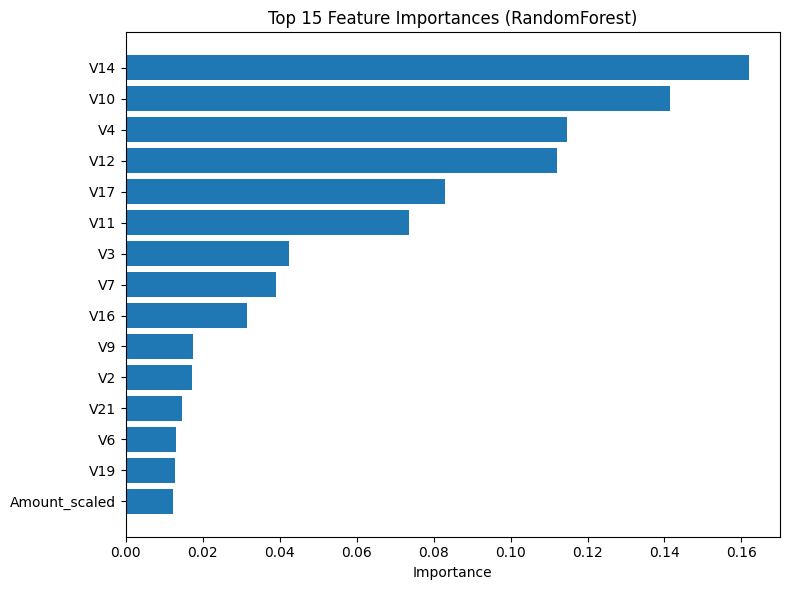

,importance
V14,0.161923
V10,0.141341
V4,0.114703
V12,0.111992
V17,0.082833
V11,0.073599
V3,0.042480
V7,0.039002
V16,0.031588
V9,0.017523


In [18]:
# RandomForest feature importance (quick)
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)

rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]

rf_roc = roc_auc_score(y_test, rf_proba)
rf_ap = average_precision_score(y_test, rf_proba)
print("RandomForest ROC-AUC:", rf_roc)
print("RandomForest PR-AUC (AP):", rf_ap)

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_k = 15
top_imp = importances.head(top_k)

plt.figure(figsize=(8, 6))
plt.barh(top_imp.index[::-1], top_imp.values[::-1])
plt.title(f"Top {top_k} Feature Importances (RandomForest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(top_imp.to_frame("importance"))


## Notes
- Dataset is extremely imbalanced → accuracy is misleading.
- PR-AUC (Average Precision) is often more meaningful for fraud retrieval.
- Threshold tuning is essential (optimize for F1 or a recall target).
- RandomForest feature importances provide a sanity-check on signals.


In [ ]:
import os

start_path=DATA_PATH

def print_tree(start_path, prefix=""):
    for item in os.listdir(start_path):
        print(prefix + "├── " + item)
        path = os.path.join(start_path, item)
        if os.path.isdir(path):
            print_tree(path, prefix + "│   ")

print_tree(".")